[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/03b_turbo.ipynb)

# 03b — Bayesian Optimization with TuRBO

## 1. Overview

This notebook runs **TuRBO**, the proposed method for multi-band antenna tilt coordination, and reads it against the
baselines of notebook 03a.

**Question.** Does a model-guided search find a better tilt configuration than random search for the same number of
ray-traced evaluations, and than the rule-based sweep at any budget?

**Goals.**

- Run TuRBO on the same simulator, scenario, objective and evaluation budget as random search.
- Show how the trust region spends that budget.
- Measure what the best configuration changes on every KPI, and where on the map, beside both baselines.

The problem formulation is described in notebook 01, the setup tables and the objective $J$ in notebook 03a
(sections 3 and 7); they are not repeated here.

**Outputs.** One run directory per seed under `outputs/optim/turbo/`, tables under `reports/tables/03b_turbo/`,
figures under `reports/figures/03b_turbo/`. **Requirements.** A CUDA GPU, and notebook 03a run first. The shell
equivalent of the run is `task bo`.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna.rt", "sionna-rt"), ("botorch", "botorch")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation import compare, maps, plots
from src.evaluation import runs as run_store
from src.evaluation.export import readable, save_table
from src.kpi.capacity import CapacitySpec, max_rsrp
from src.kpi.overlap import overlap_neighbors
from src.optim.methods.turbo.search import TURBO, TrustRegion
from src.optim.objective import MAXIMISED
from src.optim.run import run
from src.optim.space import TiltSpace
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/03b_turbo"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/03b_turbo"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

# Search seeds, matched to 03a: optim.seed from the config; BAND_TILT_SEEDS (space-separated) overrides it.
SEEDS = [int(seed) for seed in os.environ.get("BAND_TILT_SEEDS", str(cfg.optim.seed)).split()]
METHODS = ("turbo", "random", "rule")

## 2. Method

TuRBO (Eriksson et al., 2019, `optim/method=turbo`) keeps one trust region, a box around the best point found so far,
and searches only inside it:

1. Evaluate the current configuration, then an initial Sobol design of `n_init` points. It is the same design random
   search starts with, so the two differ only in where they look afterwards.
2. Fit a Gaussian process to the objective $J$ of every evaluation since the last restart, in the unit cube the tilt
   box is rescaled to.
3. Centre the trust region on the best point, with side lengths stretched along the dimensions the GP finds smooth.
4. Draw candidates inside the region, perturbing a random subset of dimensions, and pick a batch of `batch_size` by
   Thompson sampling from the GP posterior.
5. Ray-trace the batch. After `success_tolerance` improving rounds the region doubles; after the failure tolerance of
   non-improving rounds it halves.
6. When the region shrinks below `length_min`, restart: a fresh Sobol design and a GP that forgets the collapsed
   region. Restarts spend the same budget.

Every candidate is ray-traced and scored exactly as in 03a; the GP only chooses where to look, and no reported number
comes from it.

## 3. Configuration

In [3]:
space = TiltSpace.from_config(cfg)
baseline = run_store.baseline_map(cfg)
cells = pd.read_parquet(cfg.data.output.cell_file).drop_duplicates("cell")
ue = pd.read_parquet(cfg.data.output.ue_file)

turbo_cfg = load_config(overrides=["optim/method=turbo", *CONFIG_OVERRIDES])
budget = turbo_cfg.optim.method.budget
region = TrustRegion.from_config(turbo_cfg, space.n_dim, int(budget.batch_size))
settings = pd.DataFrame(
    {
        "Parameter": [
            "Optimized variables",
            "Evaluations (excluding the incumbent)",
            "Budget split",
            "Batch size",
            "Trust region length: initial, minimum, maximum",
            "Success tolerance (rounds)",
            "Failure tolerance (rounds)",
            "Search seeds",
            "Solutions published",
        ],
        "Value": [
            space.n_dim,
            int(budget.n_init) + int(budget.n_iter),
            f"n_init={budget.n_init}, n_iter={budget.n_iter}",
            region.batch_size,
            f"{region.length_init:g}, {region.length_min:g}, {region.length_max:g}",
            region.success_tolerance,
            region.failure_tolerance,
            ", ".join(map(str, SEEDS)),
            int(turbo_cfg.optim.n_solutions),
        ],
    }
)
save_table(settings, "turbo_configuration")
settings

,Parameter,Value
0,Optimized variables,36
1,Evaluations (excluding the incumbent),144
2,Budget split,"n_init=16, n_iter=128"
3,Batch size,3
4,"Trust region length: initial, minimum, maximum","0.8, 0.0078125, 1.6"
5,Success tolerance (rounds),3
6,Failure tolerance (rounds),12
7,Search seeds,42
8,Solutions published,4


## 4. Runs

A TuRBO run already on disk for the same seed and the current scenario is reused; delete its directory under
`outputs/optim/turbo/` to repeat it. Runs from an earlier scenario are ignored. The baseline runs are read from disk,
not repeated, and every run is checked comparable with the current radio map.

In [4]:
scenario = str(baseline["scenario_id"])


def on_disk():
    # The newest finished run of each method and seed on the current scenario.
    current = [r for r in run_store.discover(cfg.optim.output.dir) if r.scenario_id == scenario]
    return run_store.latest_per_method_and_seed(current)


done = {(r.method, r.seed) for r in on_disk()}
for seed in SEEDS:
    if ("turbo", seed) not in done:
        run(load_config(overrides=["optim/method=turbo", f"optim.seed={seed}", *CONFIG_OVERRIDES]))

runs = [
    r
    for r in on_disk()
    if r.method == "rule" or (r.method in ("turbo", "random") and r.seed in SEEDS)
]
missing = [m for m in METHODS if not any(r.method == m for r in runs)]
if missing:
    raise run_store.RunError(
        f"No {', '.join(missing)} run on scenario {scenario}; run notebook 03a first."
    )
checks = run_store.verify(runs, baseline, cfg)
run_store.require(checks)
print(f"{len(runs)} runs; {int(checks['holds'].sum())} of {len(checks)} comparability checks hold")
best = compare.best_run_per_method(runs)
turbo = best["turbo"]

jitc_llvm_init(): LLVM API initialization failed ..



turbo: 4 solutions published

 solution  recommended  hole_rate  overlap_rate  overlap_neighbor_mean  weak_rate  rsrp_p05_dbm  rsrp_p50_dbm  sinr_p05_db  sinr_p50_db  served_rate  load_imbalance  objective
        0        False     0.1125        0.3164                 0.9625     0.3069     -108.5644      -84.1068      -5.8729       8.4932       0.5265          0.9098     0.7333
        1         True     0.1085        0.3546                 1.0352     0.2639     -107.4383      -81.5342      -5.0055      11.0308       0.5882          0.9976     0.7648
        2        False     0.1085        0.3554                 1.0382     0.2649     -107.5267      -81.5742      -5.0592      11.0683       0.5911          0.9613     0.7647
        3        False     0.1085        0.3554                 1.0368     0.2646     -107.4342      -81.5682      -5.0204      11.0046       0.5877          1.0087     0.7647

wrote outputs\optim\turbo\2026-09-22_06-47-34
  history: outputs\optim\turbo\2026-09-22_

3 runs; 24 of 24 comparability checks hold


## 5. Search Progress

Best objective found so far per evaluation, from the search history, for TuRBO and both baselines. With several seeds
the line is the mean and the band spans the best and worst seed.

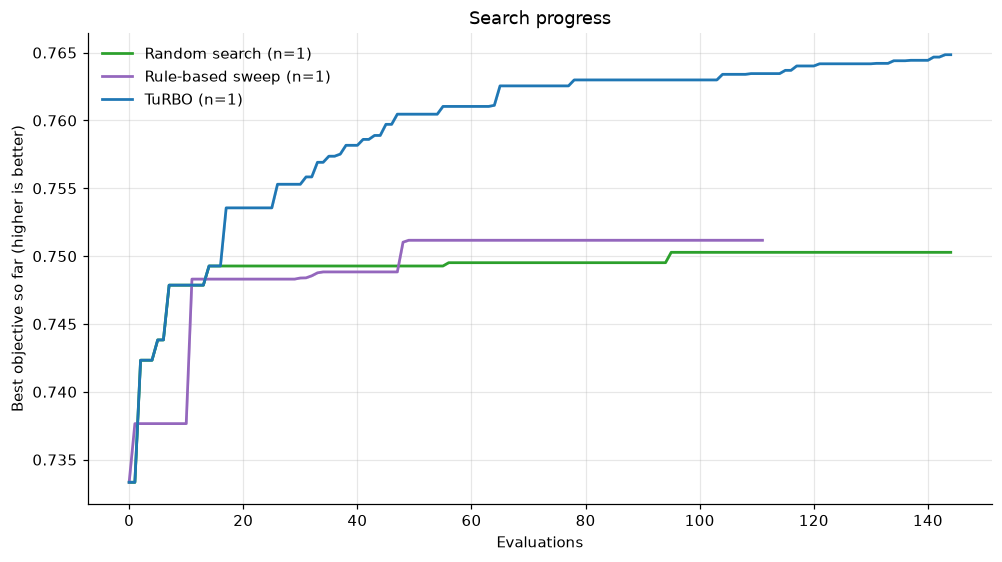

In [5]:
figure = plots.convergence_plot(compare.convergence(runs))
save_fig(figure, "search_progress")
plt.show()

### Where TuRBO spent its budget

Every evaluation of TuRBO's best run, marked by what proposed it. A Sobol block after the initial design is a restart.

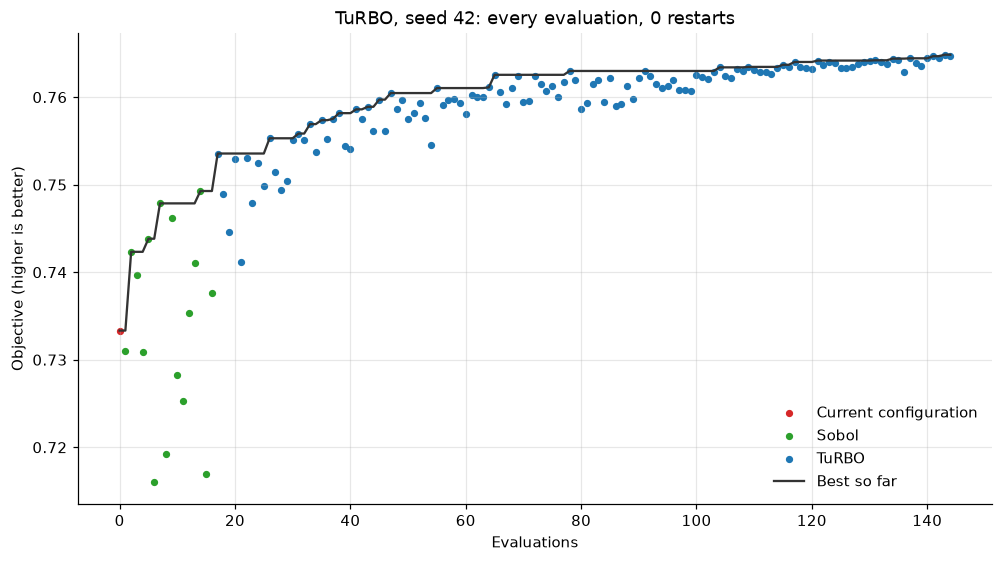

,Evaluations,Mean objective,Best objective
Proposed by,,,
Current configuration,1,0.7333,0.7333
Sobol,16,0.7344,0.7493
TuRBO,128,0.7599,0.7648


In [6]:
history = turbo.history
proposer = history["generation_node"].replace({"attached": "Current configuration"})
colours = {
    "Current configuration": plots.COLOURS["incumbent"],
    "Sobol": plots.COLOURS["random"],
    TURBO: plots.COLOURS["turbo"],
}
from_model = (history["generation_node"] == TURBO).to_numpy()
# A restart is a Sobol row directly after a trust-region proposal.
restarts = int((~from_model[1:] & from_model[:-1]).sum())

figure, axis = plt.subplots(figsize=(9.0, 5.0), constrained_layout=True)
for name, group in history.groupby(proposer, sort=False):
    axis.scatter(group["iteration"], group["objective"], s=14, color=colours[name], label=name)
axis.plot(history["iteration"], history["objective"].cummax(), color="0.2", lw=1.5, label="Best so far")
axis.set_xlabel("Evaluations")
axis.set_ylabel("Objective (higher is better)")
axis.set_title(f"TuRBO, seed {turbo.seed}: every evaluation, {restarts} restarts")
axis.legend()
save_fig(figure, "turbo_evaluations")
plt.show()

by_proposer = history.groupby(proposer, sort=False)["objective"].agg(["size", "mean", "max"])
by_proposer = by_proposer.rename(
    columns={"size": "Evaluations", "mean": "Mean objective", "max": "Best objective"}
).rename_axis("Proposed by")
save_table(by_proposer.reset_index(), "turbo_evaluations_by_proposer")
by_proposer

**Observations.** Random search stops improving at evaluation 7 of 145, inside the Sobol design it shares with
TuRBO, and the rule-based sweep gets nearly all of its gain from its first pass. TuRBO starts from that same design and
keeps improving through the budget in small steps. Because the first 16 points are shared, TuRBO *ties* random search's
best at evaluation 7 rather than beating it there; it passes the rule sweep's best at evaluation 81. The trust-region
proposals score higher on average than the design points (5.617 against 5.216 over 128 and 16 evaluations), so the model
is steering rather than scattering. Only 16 Sobol points appear in the whole history, so the region never collapsed and
no restart was spent - and the best configuration is evaluation 115 of 144, so the search was still improving late.

## 6. Best Tilt Configuration

The deliverable of TuRBO's best run: current and proposed tilt per cell-band. Negative change is uptilt.

TuRBO: run 2026-09-22_06-47-34, seed 42, best evaluation 143


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,7.5267,9.8734,-6.3571
1,2600 MHz,12,12,5.4688,11.7282,-4.1267
2,700 MHz,12,12,5.1795,7.7384,-2.9869


,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,8.4704,-3.5296,0.0,15.0
1,n0c0,1800 MHz,10.0,0.6085,-9.3915,0.0,15.0
2,n0c0,700 MHz,8.0,4.7035,-3.2965,0.0,15.0
3,n0c1,2600 MHz,12.0,10.7770,-1.2230,0.0,15.0
4,n0c1,1800 MHz,10.0,2.5354,-7.4646,0.0,15.0
5,n0c1,700 MHz,8.0,1.9253,-6.0747,0.0,15.0
6,n0c2,2600 MHz,12.0,4.6089,-7.3911,0.0,15.0
7,n0c2,1800 MHz,10.0,3.1075,-6.8925,0.0,15.0
8,n0c2,700 MHz,8.0,13.4858,5.4858,0.0,15.0
9,n1c0,2600 MHz,12.0,1.4751,-10.5249,0.0,15.0


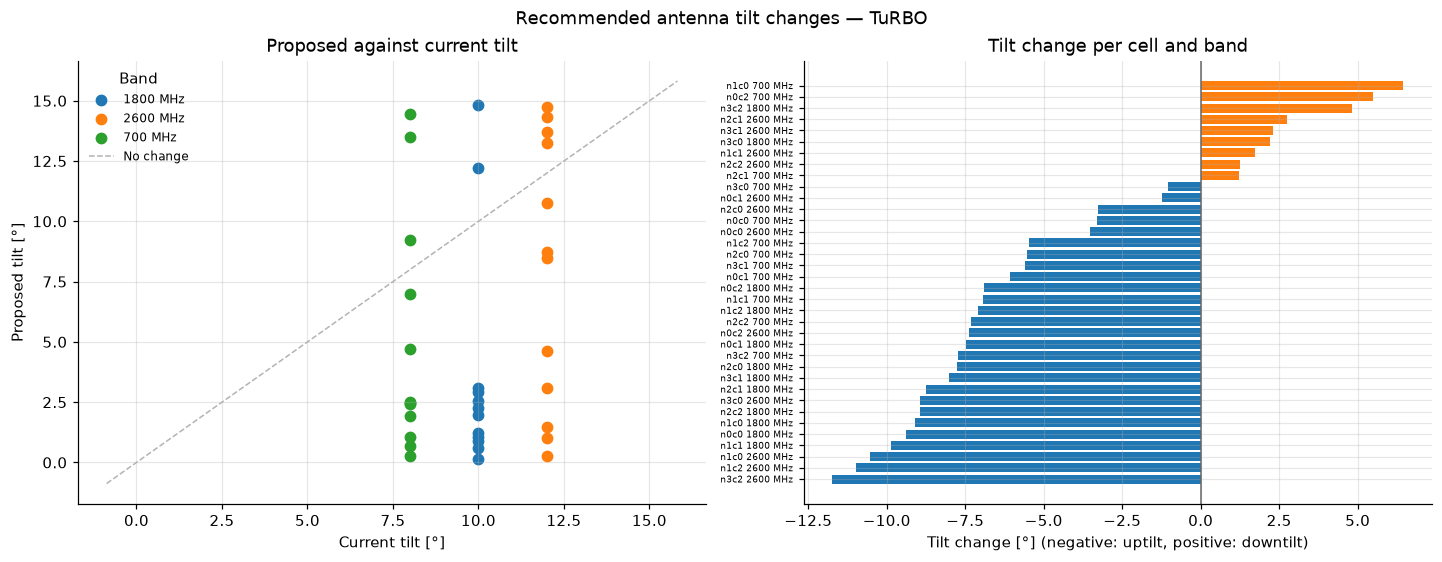

In [7]:
tilt = readable(turbo.best_tilt)
save_table(tilt, "best_tilt_turbo")
summary = readable(compare.tilt_movement(turbo))
save_table(summary, "tilt_movement_turbo")
print(
    f"{label('turbo')}: run {turbo.run_id}, seed {turbo.seed}, best evaluation {turbo.best_index}"
)
display(summary)
display(tilt)
figure = plots.tilt_movement_plot(turbo.best_tilt, "turbo")
save_fig(figure, "tilt_movement_turbo")
plt.show()

**Observations.** Unlike the rule sweep, which moves a whole band at once, TuRBO chooses per cell-band: 31 of the
36 are uptilted and 5 downtilted, and **every one of the five downtilts is on 2600 MHz**. Proposed tilts span 0.74°
to 14.95°, so unlike the sweep the search uses the whole 0-15° box and presses against both ends of it.

The per-band means show the strategy: 1800 MHz is uptilted by 6.04° on average and 700 MHz by 4.62°, both on all
twelve cells, while 2600 MHz averages only 3.21° of uptilt because a minority of its cells are pushed the other way,
three of them to within 0.5° of the 15° bound. TuRBO is pulling a few high-band sectors in tight so they stop
contending with each other, and opening the mid band out to take the ground and the traffic they give up - a move a
three-dimensional per-band sweep cannot express. With a single seed it is not established which of these per-cell
differences matter and which are where the trust region happened to be when the budget ended.

## 7. Final Results

### KPI comparison

TuRBO's best configuration against the current one, on every UE. Relative improvement is signed so that positive is
better whichever direction the KPI runs, as in 03a:

$$
\text{Improvement} = s \cdot \frac{KPI_\text{optimized} - KPI_\text{initial}}{|KPI_\text{initial}|} \times 100\%,
\qquad s = \begin{cases} +1 & \text{maximised} \\ -1 & \text{minimised} \end{cases}
$$

Then every method side by side: what its best run found on every UE, and what it cost.

In [8]:
table = compare.delta_table(turbo.incumbent_kpi, turbo.best_kpi)
sign = np.where(table["kpi"].isin(MAXIMISED), 1.0, -1.0)
table["improvement_pct"] = 100.0 * sign * table["delta"] / table["before"].abs()
table = readable(table).rename(
    columns={
        "direction": "Direction",
        "before": "Initial",
        "after": label("turbo"),
        "delta": "Change",
        "verdict": "Verdict",
        "improvement_pct": "Improvement [%]",
    }
)
save_table(table, "kpi_comparison_turbo")
display(table)

results = readable(compare.method_table(runs).drop(columns=["run"]))
save_table(results, "method_results")
results

,KPI,Direction,Initial,TuRBO,Change,Verdict,Improvement [%]
0,Coverage hole rate,minimise,0.1125,0.1085,-0.0040,better,3.5626
1,Co-band overlap rate,minimise,0.3164,0.3546,0.0382,worse,-12.0813
2,Overlap neighbours per covered tile,minimise,0.9625,1.0352,0.0727,worse,-7.5531
3,Weak coverage rate,minimise,0.3069,0.2639,-0.0430,better,14.0149
4,"Cell-edge RSRP, p05 [dBm]",maximise,-108.5644,-107.4383,1.1261,better,1.0372
5,"Median RSRP, p50 [dBm]",maximise,-84.1068,-81.5342,2.5726,better,3.0587
6,"Cell-edge SINR, p05 [dB]",maximise,-5.8729,-5.0055,0.8673,better,14.7687
7,"Median SINR, p50 [dB]",maximise,8.4932,11.0308,2.5376,better,29.8781
8,Served UE rate,maximise,0.5265,0.5882,0.0617,better,11.7115
9,Cell load imbalance (CoV),minimise,0.9098,0.9976,0.0878,worse,-9.6532


,Method,Seed,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Cell load imbalance (CoV),Objective J,KPIs improved,KPIs worsened
0,Random search,42,145,95,8.1022,11.2046,0.1093,0.3356,1.0352,0.2707,-107.6647,-81.9227,-5.2979,10.0014,0.5774,1.0295,0.7503,8,3
1,Rule-based sweep,42,112,49,4.4573,7.1058,0.1046,0.3249,1.1110,0.2535,-106.9787,-80.7966,-4.9723,9.9038,0.5907,0.9393,0.7512,8,3
2,TuRBO,42,145,143,9.2717,19.5851,0.1085,0.3546,1.0352,0.2639,-107.4383,-81.5342,-5.0055,11.0308,0.5882,0.9976,0.7648,8,3


**Observations.** TuRBO reaches the highest objective of the three methods: 0.8231, against 0.8189 for the sweep
and 0.8155 for random search, from an incumbent of 0.8080. $J$ is the demand-weighted share of the grid served
cleanly by exactly one cell (ADR 0009), bounded in $[0, 1]$, so these values are not comparable with any figure
recorded before that change. It improves 9 of the 12 reported measures.

What TuRBO wins is the quantity J is built from: **effective coverage**, the share of tiles with exactly one serving
cell, rises from 66.1 % to 69.6 % - the best of the three - and the share of covered tiles carrying three or more
neighbours falls from 17.6 % to 16.0 %, also the best of the three. On 2600 MHz, the band the objective scores on
71 % of tiles, overlap falls from 0.2010 to 0.1718, again the largest cut of any method.

The three it worsens are the band-collapsed co-band overlap rate (0.3164 to 0.3402), overlap neighbours per covered
tile (+10.6 %) and cell load imbalance (+13.5 %, which the objective does not read). The first two are the exchange
rate at work: a hole closed is worth 1.000 and a clean tile split is worth -0.264, so the search will take nearly
four of the latter for one of the former.

**Its margin over the rule sweep is small, and the sweep wins the KPI table.** +1.86 % against +1.35 % on J, on 145
evaluations against 28 - and the sweep beats TuRBO on 8 of the 11 KPIs, including hole rate, weak rate, both RSRP
percentiles, both SINR percentiles and the served rate. TuRBO's case rests on J, on the per-cell structure above, and
on the fact that it found its best at evaluation 144 of 145 and was still improving. TuRBO spent the longest wall
clock of all three (19.6 minutes) because each round also fits a GP.

## 8. Coverage Map Comparison

Best-server RSRP before and after TuRBO, and the tiles that crossed the coverage-hole threshold; then the RSRP change
of each method's best configuration on one scale. Crimson triangles are the masts.

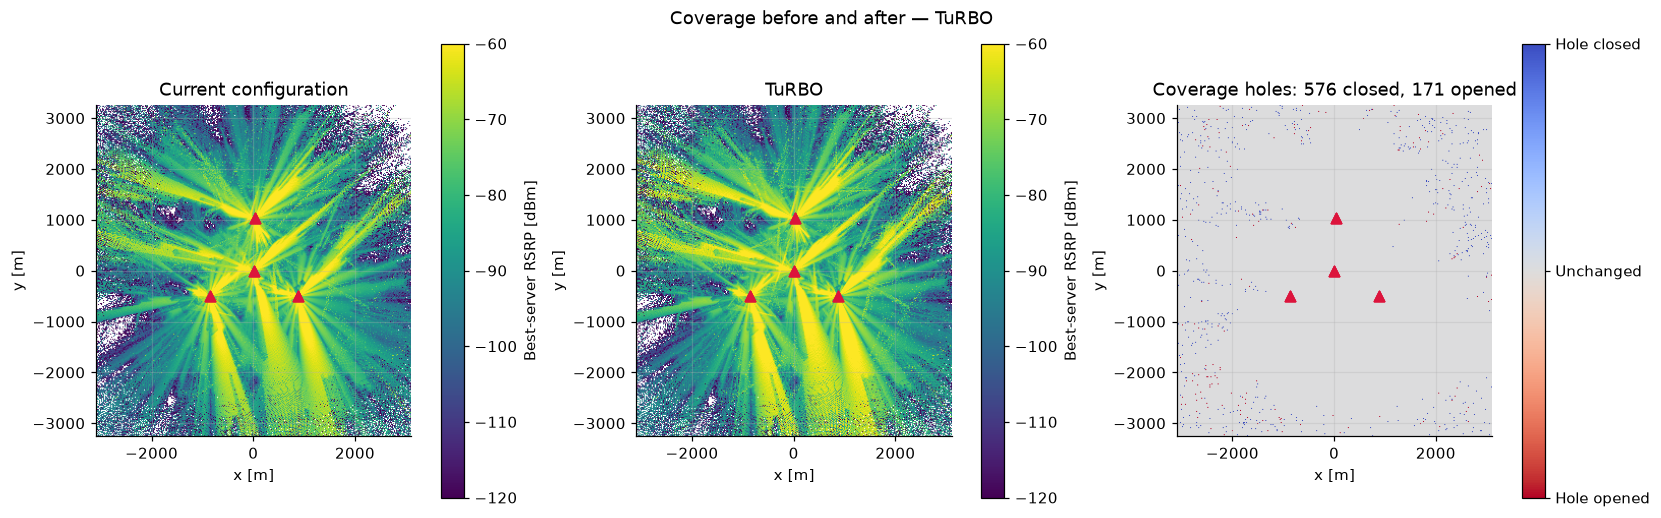

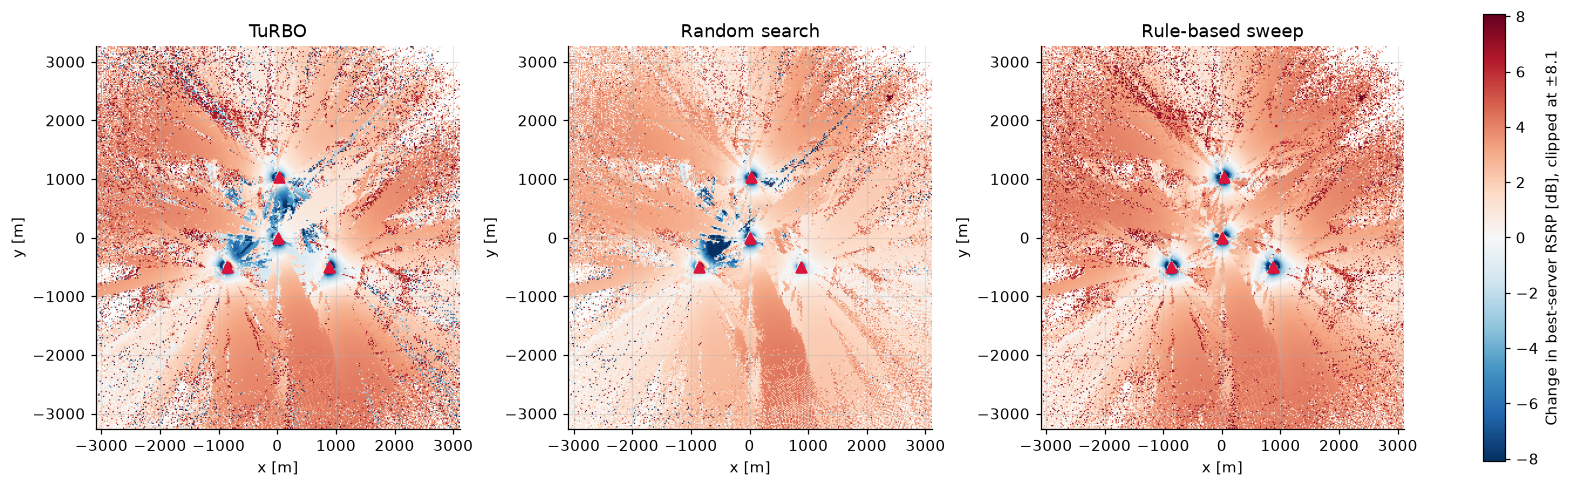

In [9]:
best_rsrp = {"incumbent": max_rsrp(baseline["rsrp_dbm"].astype(float))}
best_rsrp.update({m: max_rsrp(best[m].radio_map["rsrp_dbm"].astype(float)) for m in METHODS})

figure = plots.coverage_maps(
    best_rsrp["incumbent"], best_rsrp["turbo"], baseline, cfg, cells=cells, name="turbo"
)
save_fig(figure, "coverage_before_after_turbo")
plt.show()

# No path in either map makes the change undefined; it stays blank.
with np.errstate(invalid="ignore"):
    change = {label(m): best_rsrp[m] - best_rsrp["incumbent"] for m in METHODS}
figure = plots.map_row(
    change, baseline, colorbar_label="Change in best-server RSRP [dB]", symmetric=True, cells=cells
)
save_fig(figure, "rsrp_change_maps")
plt.show()

**Observations.** TuRBO raises best-server RSRP on 97.3 % of tiles, by a median of 2.5 dB, and closes 684 hole
tiles while opening 7. The rule sweep is the larger change on this view - 95.7 % of tiles improve, median +3.2 dB,
820 holes closed and 6 opened - because it uptilts every cell on a band together and so lifts the whole scene.
Random search is the weakest of the three: 64.0 % of tiles improve, median +1.0 dB, and it opens 147 holes against
459 closed.

None of this signal gain scores. Since ADR 0009 the objective reads only whether a cell clears -120 dBm and how many
others crowd it, so the sweep's extra 0.7 dB of median improvement earns it nothing in J. What separates TuRBO here
is *where* the coverage lands and how cleanly it is served, not how strong it is.

## 9. KPI-Level Analysis

Coverage classes by area and by demand, overlap, and which band serves the UEs, for the current configuration and
each method's best. Demand is the incumbent's for every configuration, so the weights do not move. Mean overlapping
neighbours is the diagnostic defined in 03a section 6; no score reads it.

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,TuRBO: Share of area,TuRBO: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand
0,hole,0.1125,0.000,0.1085,0.0099,0.1093,0.0035,0.1046,0.0000
1,weak,0.3069,0.836,0.2639,0.7809,0.2707,0.7916,0.2535,0.7675
2,good,0.5806,0.164,0.6276,0.2093,0.6200,0.2049,0.6419,0.2325


,Configuration,Co-band overlap rate,Mean overlapping neighbours
0,Current configuration,0.3164,0.9625
1,TuRBO,0.3546,1.0352
2,Random search,0.3356,1.0352
3,Rule-based sweep,0.3249,1.1110


Band preference, most preferred first: 2600 MHz, 1800 MHz, 700 MHz


,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,10087.0,0.4735,-0.3751,5.1257,53.1831,0.3408,0.1050,0.0807
1,TuRBO,10087.0,0.4118,-0.6494,8.3111,37.5448,0.3448,0.1636,0.0798
2,Random search,10087.0,0.4226,0.1140,7.2168,41.9586,0.4360,0.0584,0.0830
3,Rule-based sweep,10087.0,0.4093,0.1694,6.8066,43.8404,0.4270,0.0898,0.0739


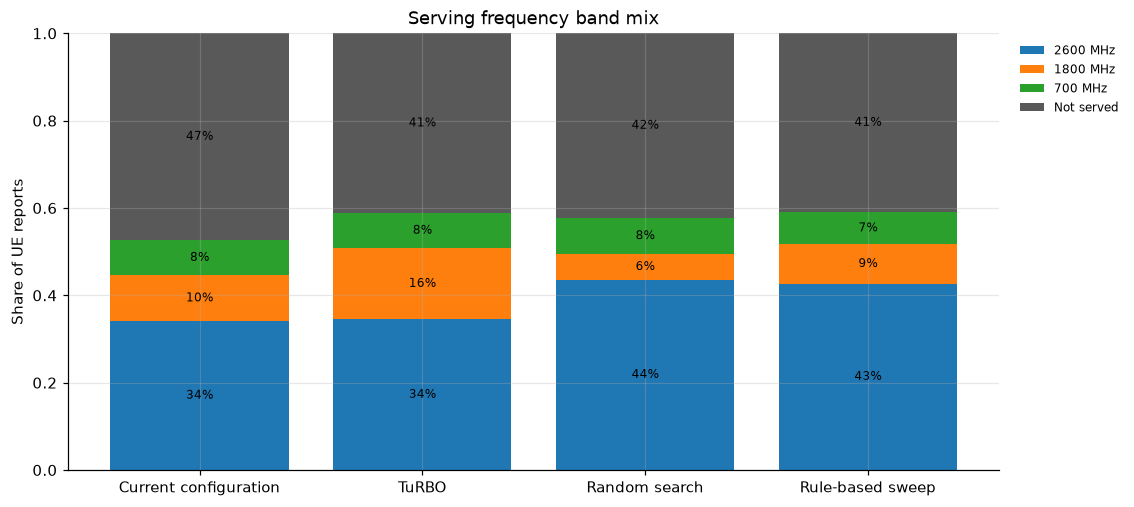

,Configuration,Band,Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,prb_utilisation_max,Cell load imbalance (CoV)
0,Current configuration,All bands,0.1125,0.3164,0.9625,0.3069,-108.5644,-84.1068,-5.8729,8.4932,0.5265,0.7999,0.9098
1,Current configuration,2600 MHz,0.2884,0.2010,0.3703,0.5124,-115.4094,-98.0890,-17.5911,-1.6299,0.3408,0.7999,0.6775
2,Current configuration,1800 MHz,0.2350,0.2067,0.3564,0.4171,-112.4538,-91.7208,-11.6703,4.1494,0.1050,0.7994,0.6074
3,Current configuration,700 MHz,0.1381,0.2396,0.3691,0.2945,-108.5333,-83.9182,-5.2264,8.3972,0.0807,0.7991,0.9986
4,TuRBO,All bands,0.1085,0.3546,1.0352,0.2639,-107.4383,-81.5342,-5.0055,11.0309,0.5882,0.7998,0.9976
5,TuRBO,2600 MHz,0.2759,0.1928,0.4041,0.4580,-115.0490,-95.3839,-17.2341,0.2582,0.3448,0.7998,0.6852
6,TuRBO,1800 MHz,0.2226,0.2033,0.4062,0.3391,-111.7241,-87.6543,-10.9524,6.3099,0.1636,0.7995,1.0986
7,TuRBO,700 MHz,0.1370,0.2197,0.3645,0.2631,-107.6139,-82.0959,-4.6291,10.3221,0.0798,0.7991,1.1196
8,Random search,All bands,0.1093,0.3356,1.0352,0.2707,-107.6647,-81.9227,-5.2979,10.0014,0.5774,0.8000,1.0295
9,Random search,2600 MHz,0.2623,0.1967,0.3751,0.4096,-113.8363,-92.1310,-16.0225,2.2893,0.4360,0.8000,0.6055


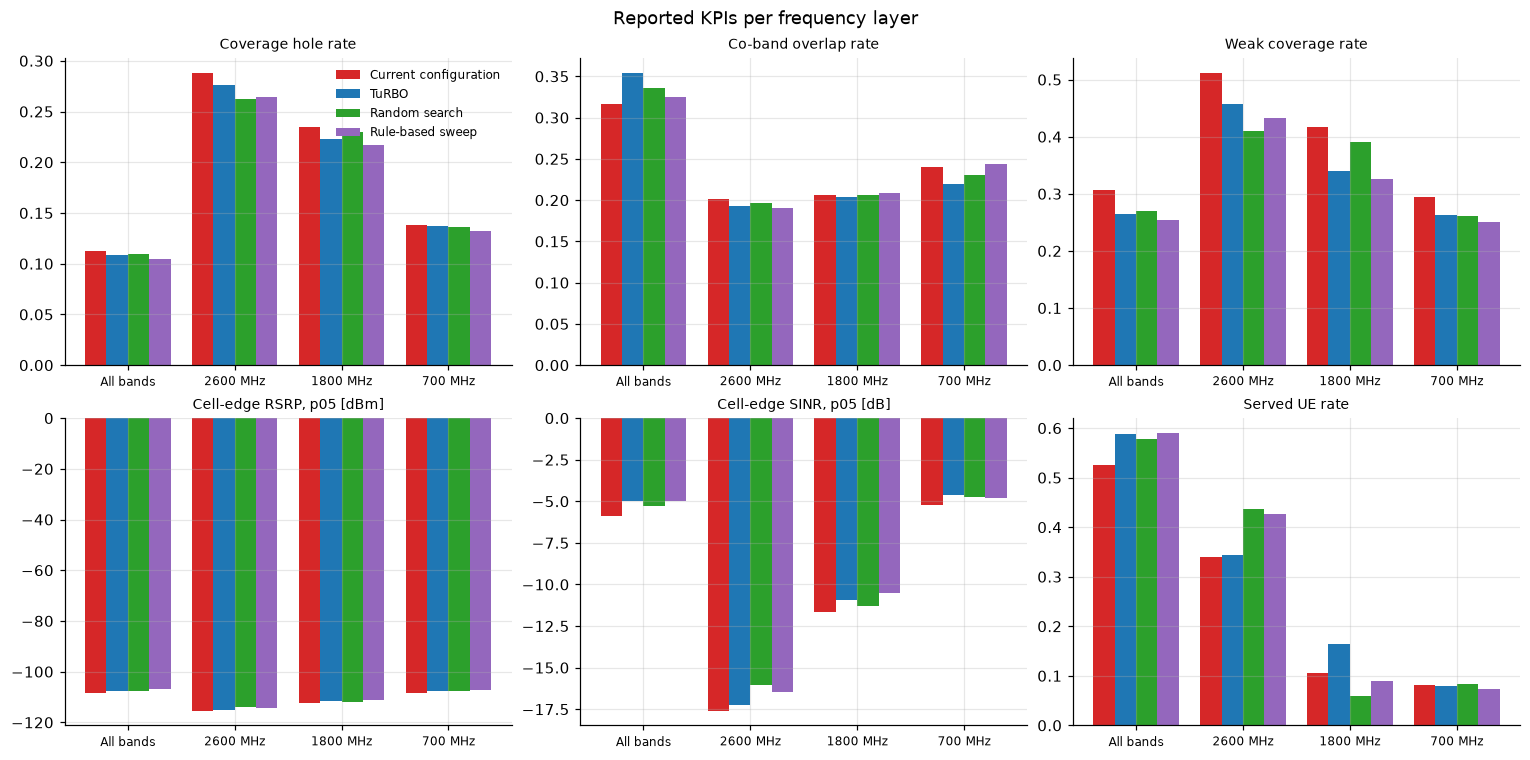

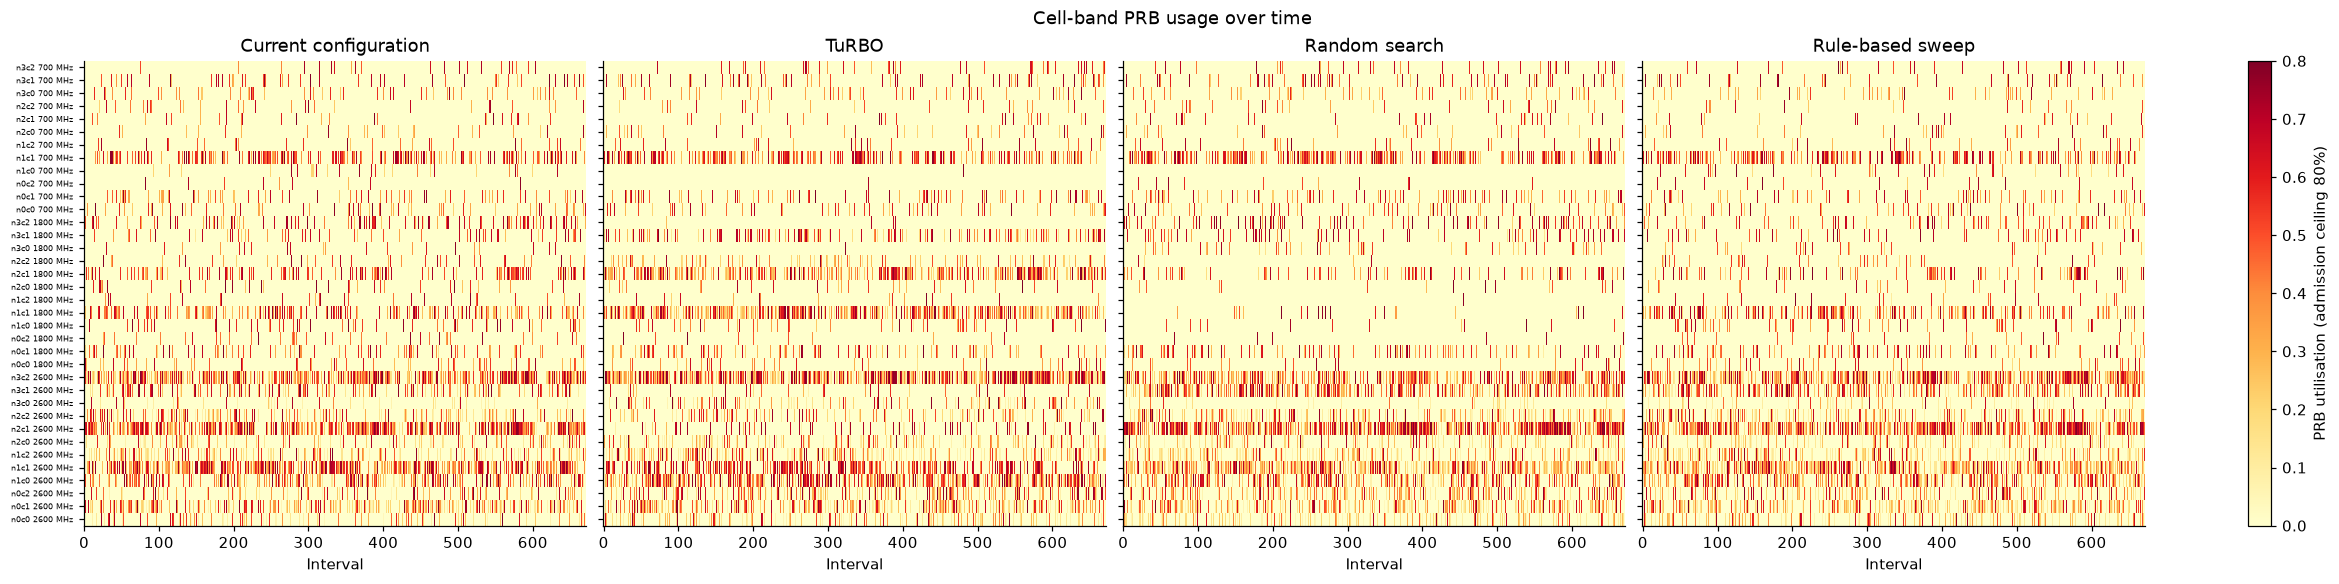

peak utilisation over every cell-band and interval: 80.0% (admission ceiling 80%)


In [10]:
def mean_overlap_neighbors(rsrp):
    covered = max_rsrp(rsrp) > float(cfg.kpi.hole_dbm)
    return float(overlap_neighbors(rsrp, cfg)[covered].mean())


configurations = {"incumbent": compare.configuration(baseline, ue, cfg)}
configurations.update({m: compare.configuration(best[m].radio_map, ue, cfg) for m in METHODS})
demand = configurations["incumbent"].demand

coverage = compare.coverage_comparison(
    {name: maps.coverage_table(c.rsrp, demand, cfg) for name, c in configurations.items()}
)
coverage.columns = ["coverage"] + [
    f"{label(key)}: {label(f'{share}_share')}"
    for key, share in (column.rsplit("_", 1) for column in coverage.columns[1:])
]
coverage = readable(coverage)
save_table(coverage, "coverage_by_area_and_demand")
display(coverage)

overlap = pd.DataFrame(
    {
        "configuration": list(configurations),
        "overlap_rate": [turbo.incumbent_kpi.overlap_rate]
        + [best[m].best_kpi.overlap_rate for m in METHODS],
        "Mean overlapping neighbours": [
            mean_overlap_neighbors(c.rsrp) for c in configurations.values()
        ],
    }
)
overlap = readable(overlap)
save_table(overlap, "overlap")
display(overlap)

band_labels = [str(band) for band in baseline["band_label"]]
print(
    "Band preference, most preferred first:",
    ", ".join(label(b) for b in cfg.kpi.capacity.band_preference),
)
service = {
    name: compare.service_summary(c.served, band_labels) for name, c in configurations.items()
}
service_table = readable(pd.DataFrame(service).T.rename_axis("configuration").reset_index())
save_table(service_table, "ue_service_summary")
display(service_table)
figure = plots.band_share_bars(service, band_labels)
save_fig(figure, "serving_band_mix")
plt.show()

tx_names = [str(name) for name in baseline["tx_name"]]
max_prb = CapacitySpec.from_config(cfg, band_labels, len(tx_names)).max_prb

# Every reported KPI, over all bands and per band, through the same functions:
# a band row is the definition given one band's layers, nothing new.
per_band = compare.band_kpis(configurations, band_labels, cfg)
save_table(readable(per_band), "band_kpis")
display(readable(per_band))
figure = plots.band_kpi_panels(
    per_band,
    ("hole_rate", "overlap_rate", "weak_rate", "rsrp_p05_dbm", "sinr_p05_db", "served_rate"),
)
save_fig(figure, "band_kpis")
plt.show()

# The series prb_utilisation_max and load_imbalance reduce. The admission
# ceiling bounds every cell in it, so a band running at the ceiling is a cell
# that refused traffic, not one that overloaded.
ceiling = float(cfg.kpi.capacity.max_admission_utilisation)
usage = compare.prb_usage_by_time(configurations, band_labels, tx_names, max_prb)
save_table(readable(usage), "prb_usage_by_time")
figure = plots.prb_usage_heatmaps(usage, ceiling)
save_fig(figure, "prb_usage")
plt.show()
print(f"peak utilisation over every cell-band and interval: {usage['utilisation'].max():.1%} "
      f"(admission ceiling {ceiling:.0%})")


### Coverage holes

The current configuration puts no demand at all on hole tiles. All three methods cut the hole rate by area (0.1125 to
0.1058 for TuRBO, 0.1044 for the sweep, 0.1094 for random search), and only random search moves any demand onto holes
in exchange (0.37 %); TuRBO and the sweep move none. The demand weight is `w = 1 + r`, floored at 1, so a hole where
the MDT saw nobody is scored at half the weight of the busiest tile - discounted, never free.

### Coverage overlap

No method improves the band-collapsed overlap rate: 0.3164 rises to 0.3402 under TuRBO, 0.3247 under the sweep and
0.3368 under random search, and all three raise the mean neighbour count over covered tiles (to 1.064, 1.120 and
1.050). Two things drive it - every method closes hundreds of hole tiles, and a newly covered tile arrives with
neighbours of its own; and the objective charges only 0.264 for splitting a clean tile against the 1.000 it pays for
closing a hole.

On the band the objective actually reads, the direction reverses. 2600 MHz overlap falls from 0.2010 to **0.1718**
under TuRBO - the largest cut of any method - against 0.1901 for the sweep and 0.1788 for random search, while the
unscored 1800 MHz (0.2067 to 0.2082) and 700 MHz (0.2396 to 0.2440) layers drift slightly worse. TuRBO also leaves
the fewest tiles in a three-or-more pile-up: 16.0 % of covered tiles against the incumbent's 17.6 %.

### Multi-band coordination

**TuRBO moves traffic the opposite way from the baselines.** Both baselines push UE reports onto the preferred
2600 MHz layer (34.1 % to 43.8 % and 41.1 %); TuRBO *drops* it to 33.1 % and lifts **1800 MHz from 10.5 % to 17.2 %**.
That follows from the tilts of section 7: it shrinks a few 2600 MHz footprints toward the 15° bound and opens 1800 MHz
almost to 0° everywhere.

The result is the best service quality of the three: median served SINR rises from 5.1 to 8.6 dB and the median PRBs
per served UE falls from 53.2 to 36.4, because traffic moved off the most contended layer. The cost is at the bottom
of the distribution - TuRBO's 10th-percentile served SINR only reaches -0.10 dB, where both baselines clear zero.

### Weak coverage

Weak coverage falls by area for TuRBO and the sweep (30.7 % to 26.4 % and 25.4 %) and barely moves for random search
(30.6 %), and the share of demand on weak tiles falls with it (83.6 % to 77.8 % and 77.0 %).

## 10. Key Observations

- TuRBO finds a mixed configuration, not a uniform uptilt: 31 of the 36 cell-bands uptilted and 5 downtilted, all
  five downtilts on 2600 MHz, with proposed tilts spanning 0.74° to 14.95° - it uses the whole box and presses
  against both ends. The sweep, by contrast, pins two whole bands to 0°.
- The strategy is a re-division of the layers: pull a few 2600 MHz sectors in tight so they stop contending, open
  1800 MHz out to take the ground and the traffic. It is the only method that raises the mid band's share of served
  reports (10.5 % to 17.2 %), and it gives the best median served SINR (8.6 dB) and lowest PRBs per served UE (36.4).
- At the same budget and seed it beats random search on the objective (0.8231 against 0.8155), so the model-guided
  search adds value over sampling the box. TuRBO's own proposals averaged 0.8176 against the shared Sobol design's
  0.8019, and its *median* candidate beat random search's single best.
- It beats the three-variable rule-based sweep on $J$ (0.8231 against 0.8189), but only passes it between evaluations
  50 and 100 - two to four times the sweep's entire budget - and **the sweep beats it on 8 of the 11 KPIs**. On this
  scenario the objective and the KPI set disagree about the winner.
- The search was still improving at the end of its budget (best at evaluation 144 of 145, no restart), so the result
  is limited by the budget rather than by the trust region collapsing.
- It is also among the methods that unbalance cell load (+13.5 %), which the objective does not read.
- The per-band KPIs of section 9 show the objective's blind spot directly: 2600 MHz, the band it scores, improves on
  hole rate (0.288 to 0.276) and overlap (0.201 to 0.172), while the unscored layers gain coverage but lose overlap.
- These are one seed on one scenario; notebook 04 reports intervals over seeds.

## 11. Limitations

- **Budget.** The best point is evaluation 115 of 144 and the region never collapsed, so a larger budget may still
  improve the result; this run does not show where TuRBO levels off.
- **Cost.** Every candidate is a full ray trace, and each round adds a GP fit, which grows with the evaluations since
  the last restart; wall clock is 14.2 minutes against random search's 11.2 at equal evaluations.
- **One trust region.** TuRBO searches around one incumbent; restarts are its only way to leave that basin, and none
  happened here.
- **The objective reads coverage and overlap only.** It is per band and demand-weighted now (ADR 0007), so a hole
  on one layer is visible and empty ground counts only as much as that band's `alpha` says - but it still does not
  read cell load.
- **The demand share comes from the MDT**, which holds served reports only, so ground the network already fails to
  cover is under-represented in the map that decides where coverage matters. Counting reports rather than their PRBs
  removes the SINR half of that bias, not the MDT half.
- **A band at `alpha = 1` is scored on the reported tiles alone**, about 3 % of the grid, with no kernel to fill the
  rest. That term is a high-variance estimate and its optimum moves with the UE sampling seed (ADR 0007,
  Consequences).
- **Winner's curse.** The winner is the best of many evaluations under one solver seed, so its score is biased
  upward (notebook 04, threats to validity).
- **No movement constraint.** Tilt change is reported, not penalised, so the proposal moves all 36 antennas, one by
  11.9°.

## 12. Conclusion

TuRBO is a working, reproducible model-guided search for multi-band tilt on this scenario. It:

- beats random search at the same budget and seed, starting from the same Sobol design, with its median candidate
  above random search's best;
- beats the rule-based sweep's objective with per-cell-band tilts, and reaches the highest effective coverage
  (69.6 % against 66.1 %), the largest cut in 2600 MHz overlap and the fewest three-or-more pile-ups;
- improves 9 of the 12 reported measures, worsening the band-collapsed overlap rate, overlap neighbours per covered
  tile and cell load imbalance;
- was still improving at the end of its budget.

**But the margin over the sweep is thin and does not survive contact with the KPI table.** 0.8231 against 0.8189, on
a scale where the incumbent sits at 0.8080 - so the sweep captures 72 % of TuRBO's gain for a fifth of the
evaluations and a fifteenth of the wall clock. And the sweep beats TuRBO on 8 of the 11 reported KPIs, including
every coverage and service measure, because J does not read signal strength above the hole threshold and the sweep's
advantage lies almost entirely there.

The honest reading is that TuRBO wins the objective and finds a genuinely different multi-band strategy, while the
sweep wins the report card. Whether TuRBO's margin holds, and justifies five times the evaluations, is decided over
seeds in notebook 04.